In [1]:
#!/usr/bin/env python
# coding: utf-8

# In[5]:


#!/usr/bin/env python
# coding: utf-8
"""
B-Pillar CGNN v2 - Improved Demo Code
Synod design deliberation 결과 반영:
  1. Per-block FiLM Generators (4개 독립 generator)
  2. compute_smoothness_loss 수정: 절대 엣지 길이 → 상대 변화량 기반
  3. 그래디언트 클리핑 추가 (IFT 역전파 안정성)
  4. Section continuity loss 추가 (3D 형상 연속성)
  5. Monotonicity loss 추가 (Inner < Reinf < Outer Y좌표 순서 강제)
  6. 코드 일관성: in_channels=7 명시적 기본값, base_coords 전달 구조화
"""

import matplotlib.pyplot as plt
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


## ─────────────────────────────────────────────────────────────
## Full Plastic Moment (Differentiable via IFT)
## ─────────────────────────────────────────────────────────────

class ImplicitPNASolver(torch.autograd.Function):
    """
    미분 가능한 소성 중립축(PNA) 및 전소성 모멘트(Mp) 계산기
    Forward : Bisection으로 인장력=압축력 평형점(y_pna) 탐색
    Backward: IFT로 ∂y_pna/∂coords 계산 → chain-rule로 ∂Mp/∂coords 전파
    """

    @staticmethod
    def forward(ctx, coords, t, fy, edge_index, n_iter=30):
        with torch.no_grad():
            y = coords[:, 1]
            t_flat = t.squeeze(-1)
            fy_flat = fy.squeeze(-1)

            y_lo = y.min().clone()
            y_hi = y.max().clone()

            for _ in range(n_iter):
                y_mid = 0.5 * (y_lo + y_hi)
                F_tens = torch.sum(t_flat * fy_flat * torch.clamp(y - y_mid, min=0.0))
                F_comp = torch.sum(t_flat * fy_flat * torch.clamp(y_mid - y, min=0.0))
                if F_tens > F_comp:
                    y_lo = y_mid
                else:
                    y_hi = y_mid

            y_pna = 0.5 * (y_lo + y_hi)

        d = torch.abs(coords[:, 1] - y_pna)
        area = t_flat
        mp_pred = torch.sum(area * fy_flat * d)

        ctx.save_for_backward(coords, t, fy, y_pna.unsqueeze(0), edge_index)
        return mp_pred

    @staticmethod
    def backward(ctx, grad_output):
        coords, t, fy, y_pna_buf, edge_index = ctx.saved_tensors
        y_pna = y_pna_buf.squeeze(0)

        y = coords[:, 1]
        t_flat = t.squeeze(-1)
        fy_flat = fy.squeeze(-1)
        s = torch.sign(y - y_pna)

        dg_dy_pna = -torch.sum(t_flat * fy_flat)
        dg_dy = s * t_flat * fy_flat
        dy_pna_dy = -dg_dy / (dg_dy_pna + 1e-12)

        direct = t_flat * fy_flat * s
        indirect = -torch.sum(t_flat * fy_flat * s) * dy_pna_dy
        dMp_dy = direct + indirect

        grad_coords = torch.zeros_like(coords)
        grad_coords[:, 1] = grad_output * dMp_dy

        return grad_coords, None, None, None, None


def calculate_mpl(coords, t, fy, edge_index):
    return ImplicitPNASolver.apply(coords, t, fy, edge_index)

/home/hyu31/miniforge3/envs/GNN/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## ─────────────────────────────────────────────────────────────
## Model Architecture (v2)
## ─────────────────────────────────────────────────────────────

class FiLMGenerator(nn.Module):
    """target_mp [B, 1] → (gamma, beta) [B, hidden]

    Fix 1: target_mp 정규화 (1,500,000 → 1.5) — 미정규화 시 Linear 가중치에 의해
            gamma/beta ≈ ±3.6M 발생 → h = gamma*h + beta로 hidden state 완전 파괴
    Fix 2: 마지막 레이어 zero-init → 초기 delta_gamma≈0, beta≈0 → identity mapping 보장
    Fix 3: (1 + delta_gamma) 공식 → 초기 gamma=1, 안정적 학습 시작
    """
    MP_SCALE = 1e6  # 1,500,000 → 1.5, 1,000,000 → 1.0

    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )
        ## 마지막 레이어 zero-init: 초기 delta_gamma=0, beta=0 → h = (1+0)*h + 0 = h
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, target_mp):
        ## 정규화: 1,500,000 → 1.5, 1,000,000 → 1.0
        target_mp_norm = target_mp / self.MP_SCALE
        out = self.net(target_mp_norm)
        delta_gamma, beta = torch.chunk(out, 2, dim=-1)
        ## Identity mapping 유도: gamma = 1 + δγ (초기 δγ≈0 → gamma≈1)
        gamma = 1.0 + delta_gamma
        return gamma, beta


class CGDNBlock(nn.Module):
    """GATv2Conv → LayerNorm → FiLM modulation → GELU → Residual  (AdaIN pattern)

    Fix: Norm을 FiLM 앞으로 이동 (Gemini/OpenAI/Claude 3모델 동의)
    이전: conv → FiLM → Norm → GELU → residual
          LayerNorm이 FiLM이 주입한 target_mp 정보를 즉시 소거 → 조건부 학습 불가
    수정: conv → Norm → FiLM → GELU → residual  (AdaIN 패턴)
          Norm으로 특징 정규화 후 FiLM으로 조건 주입 → 조건 정보가 보존됨
    """
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h)              ## Normalize FIRST (AdaIN pattern)
        h = gamma * h + beta          ## FiLM AFTER norm → conditioning preserved
        h = F.gelu(h)
        h = h + h_res
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network (v2)

    v2 개선사항:
    - film_generators: ModuleList (블록별 독립 FiLM Generator)
      → 각 GATv2 블록이 서로 다른 수준의 Mp 조건 표현 학습

    입력 노드 특징 (in_channels=7):
        [x, y, is_fixed, part_id, section_id, t, fy]
    엣지 특징 (edge_dim=4):
        [길이, 각도, part_id, edge_type]
    조건부 입력:
        target_mp [N, 1] (노드별 목표 전소성 모멘트)
    """

    def __init__(
        self,
        in_channels: int = 7,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,
    ):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers

        ## 1. Node Encoder
        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )

        ## 2. Per-block FiLM Generators (v2 핵심 변경)
        ##    이전: 단일 film_gen 공유 → 모든 블록이 같은 γ,β 사용
        ##    v2:   블록별 독립 film_gen → 각 레이어가 고유한 조건 표현 학습
        self.film_generators = nn.ModuleList([
            FiLMGenerator(hidden_channels) for _ in range(num_layers)
        ])

        ## 3. GATv2 Message-Passing Blocks
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])

        ## 4. Coordinate Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),
        )

    def forward(self, x, edge_index, edge_attr, target_mp, is_fixed_mask):
        """
        x             : [N, in_channels]  노드 특징
        edge_index    : [2, E]
        edge_attr     : [E, edge_dim]
        target_mp     : [N, 1]   노드별 목표 전소성 모멘트
        is_fixed_mask : [N, 1]   고정점 Boolean 마스크
        """
        h = self.node_encoder(x)

        ## Per-block FiLM conditioning (v2)
        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)   # 블록별 독립 γ,β
            h = block(h, edge_index, edge_attr, gamma, beta)

        delta_coords = self.decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)
        delta_coords = delta_coords * (~is_fixed_mask).float()  # Hard constraint

        new_coords = x[:, :2] + delta_coords
        return new_coords, delta_coords


## ─────────────────────────────────────────────────────────────
## Loss Functions (v2)
## ─────────────────────────────────────────────────────────────

def compute_smoothness_loss(new_coords, base_coords, edge_index):
    """
    v2 수정: 절대 엣지 길이 → 초기 엣지 대비 상대 변화량 최소화
    이전: mean(||c_i - c_j||²)  → 모든 엣지를 0으로 만들려 함 (버그)
    v2:   mean(((L_new - L_base) / L_base)²)  → 형상 변화량 제한
    """
    src, dst = edge_index
    new_diff = new_coords[src] - new_coords[dst]
    base_diff = base_coords[src] - base_coords[dst]
    new_len = torch.norm(new_diff, dim=1)
    base_len = torch.norm(base_diff, dim=1)
    rel_change = (new_len - base_len) / (base_len + 1e-6)
    return torch.mean(rel_change ** 2)


def compute_collision_loss(new_coords, part_ids, section_ids, margin=0.5):
    """층별 다중 파트 간섭 방지 (Y좌표 기반)"""
    total_collision_loss = torch.tensor(0.0, device=new_coords.device)
    unique_sections = torch.unique(section_ids)

    for lvl in unique_sections:
        lvl_mask = (section_ids == lvl)
        y_lvl = new_coords[lvl_mask, 1]
        p_lvl = part_ids[lvl_mask]

        mask_1 = (p_lvl == 0)  # Outer
        mask_2 = (p_lvl == 1)  # Reinf
        mask_3 = (p_lvl == 2)  # Inner

        if mask_2.any() and mask_3.any():
            gap_3_2 = torch.clamp(y_lvl[mask_3].max() - y_lvl[mask_2].min() + margin, min=0.0)
            total_collision_loss += gap_3_2 ** 2
            gap_2_1 = torch.clamp(y_lvl[mask_2].max() - y_lvl[mask_1].min() + margin, min=0.0)
            total_collision_loss += gap_2_1 ** 2
        elif mask_3.any() and mask_1.any():
            gap_3_1 = torch.clamp(y_lvl[mask_3].max() - y_lvl[mask_1].min() + margin, min=0.0)
            total_collision_loss += gap_3_1 ** 2

    return total_collision_loss


def compute_monotonicity_loss(new_coords, part_ids, section_ids, margin=2.0):
    """
    v2 추가: Inner < Reinf < Outer Y좌표 순서를 Soft constraint로 강제
    collision_loss를 보완하여 파트 간 Y 순서 단조성 보장
    margin=2.0mm: collision_loss의 0.5mm보다 넓어 조기 경고 역할
    """
    loss = torch.tensor(0.0, device=new_coords.device)
    unique_sections = torch.unique(section_ids)

    for sec in unique_sections:
        mask = (section_ids == sec)
        y_sec = new_coords[mask, 1]
        p_sec = part_ids[mask]

        y_outer = y_sec[p_sec == 0]  # Outer
        y_inner = y_sec[p_sec == 2]  # Inner

        if y_outer.numel() > 0 and y_inner.numel() > 0:
            # Inner 최대 Y < Outer 최소 Y (margin 포함)
            loss += torch.relu(y_inner.max() - y_outer.min() + margin) ** 2

            if (p_sec == 1).any():  # Reinf 존재 시 추가 단조성
                y_reinf = y_sec[p_sec == 1]
                loss += torch.relu(y_inner.max() - y_reinf.min() + margin) ** 2
                loss += torch.relu(y_reinf.max() - y_outer.min() + margin) ** 2

    return loss


def compute_section_continuity_loss(new_coords, base_coords, section_ids, part_ids):
    """
    v2 추가: 인접 섹션 간 같은 파트의 변위 변화 균일성 강제
    동일 part의 인접 section 노드들이 비슷한 양으로 변형되도록 유도
    → 섹션 간 단차/뒤틀림 방지
    """
    loss = torch.tensor(0.0, device=new_coords.device)
    delta = new_coords - base_coords  # [N, 2] 전체 변위

    unique_sections = torch.unique(section_ids)
    unique_parts = torch.unique(part_ids)

    for i in range(len(unique_sections) - 1):
        sec_a = unique_sections[i]
        sec_b = unique_sections[i + 1]

        for part in unique_parts:
            mask_a = (section_ids == sec_a) & (part_ids == part)
            mask_b = (section_ids == sec_b) & (part_ids == part)

            if mask_a.any() and mask_b.any():
                delta_a = delta[mask_a]  # [n, 2]
                delta_b = delta[mask_b]  # [m, 2]
                # 같은 파트 인접 섹션 간 평균 변위 차이 최소화
                mean_delta_a = delta_a.mean(dim=0)
                mean_delta_b = delta_b.mean(dim=0)
                loss += torch.sum((mean_delta_b - mean_delta_a) ** 2)

    return loss


def compute_mass_loss(new_coords, t, edge_index):
    src, dst = edge_index
    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    t_src = t[src].squeeze(-1)
    area = torch.sum(seg_len * t_src)
    return area

In [3]:

## ─────────────────────────────────────────────────────────────
## Training Step (v2)
## ─────────────────────────────────────────────────────────────

def train_step(model, data, optimizer, target_mps,
               w_phys=10000000.0, w_smooth=0.01, w_mass=0.0001,
               w_collision=10.0, w_fix=100.0,
               w_monotone=10.0, w_continuity=1.0,
               max_grad_norm=1.0):
    """
    v2 변경사항:
    - base_coords를 compute_smoothness_loss에 전달
    - section_continuity_loss, monotonicity_loss 추가
    - 그래디언트 클리핑 추가 (IFT 안정성)
    - w_smooth 조정: 0.01 → 0.1 (상대 변화량 기준으로 scale 변경)
    """
    model.train()
    optimizer.zero_grad()

    x          = data.x                          ## [N, 7]
    edge_index = data.edge_index                 ## [2, E]
    edge_attr  = data.edge_attr                  ## [E, 4]
    base_coords = data.x[:, :2].detach()         ## [N, 2] 초기 좌표 (역전파 차단)

    is_fixed_mask = x[:, 2].bool().unsqueeze(1)
    part_ids      = x[:, 3]
    section_ids   = x[:, 4]
    t             = x[:, 5].unsqueeze(1)
    fy            = x[:, 6].unsqueeze(1)

    unique_sections = torch.unique(section_ids)

    ## ── 노드별 목표 Mp 텐서 생성 ──
    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=x.device)
    for section in unique_sections:
        section_mask = (section_ids == section)
        section_int = int(section.item())
        target_mp_node[section_mask] = target_mps[section_int]

    ## ── GNN Forward Pass ──
    new_coords, delta_coords = model(x, edge_index, edge_attr, target_mp_node, is_fixed_mask)

    ## ── 층별 물리 손실 (L_phys) ──
    l_phys_total = torch.tensor(0.0, device=x.device)
    pred_mp_sections = []

    for section in unique_sections:
        section_mask = (section_ids == section)
        coords_section = new_coords[section_mask]
        t_section = t[section_mask]
        fy_section = fy[section_mask]

        pred_mp_section = calculate_mpl(coords_section, t_section, fy_section, None)
        section_int = int(section.item())
        target_mp_section = torch.tensor(target_mps[section_int], dtype=torch.float32, device=x.device)

        l_phys_section = ((pred_mp_section - target_mp_section) / target_mp_section) ** 2
        l_phys_total += l_phys_section.squeeze()
        pred_mp_sections.append(pred_mp_section.item())

    num_sections = len(unique_sections)
    l_phys_total = l_phys_total / num_sections
    pred_mp_sections = np.array(pred_mp_sections)

    ## ── 다목적 손실 계산 ──
    # v2: smoothness에 base_coords 전달 (상대 변화량 기준)
    l_smooth = compute_smoothness_loss(new_coords, base_coords, edge_index)
    l_mass = compute_mass_loss(new_coords, t, edge_index)
    l_collision = compute_collision_loss(new_coords, part_ids, section_ids)

    # v2 추가 손실
    l_monotone = compute_monotonicity_loss(new_coords, part_ids, section_ids)
    l_continuity = compute_section_continuity_loss(new_coords, base_coords, section_ids, part_ids)

    fixed_nodes = is_fixed_mask.squeeze()
    if fixed_nodes.any():
        l_fix = torch.sum(torch.norm(delta_coords[fixed_nodes], dim=1))
    else:
        l_fix = torch.tensor(0.0, device=x.device)

    ## ── Total Loss ──
    loss = (w_phys      * l_phys_total
          + w_smooth    * l_smooth
          + w_mass      * l_mass
          + w_collision * l_collision
          + w_fix       * l_fix
          + w_monotone  * l_monotone      # v2 추가
          + w_continuity * l_continuity)  # v2 추가

    loss.backward()

    ## v2 추가: 그래디언트 클리핑 (IFT 역전파 안정성)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)

    optimizer.step()

    return {
        "loss":          loss.item(),
        "pred_mp":       pred_mp_sections,
        "l_phys":        l_phys_total.item(),
        "l_smooth":      l_smooth.item(),
        "l_mass":        l_mass.item(),
        "l_collision":   l_collision.item(),
        "l_fix":         l_fix.item() if isinstance(l_fix, torch.Tensor) else l_fix,
        "l_monotone":    l_monotone.item(),
        "l_continuity":  l_continuity.item(),
        "new_coords":    new_coords.detach(),
    }

Nodes: torch.Size([80, 7]) | Edges: torch.Size([2, 272]) | Edge Features: torch.Size([272, 4])


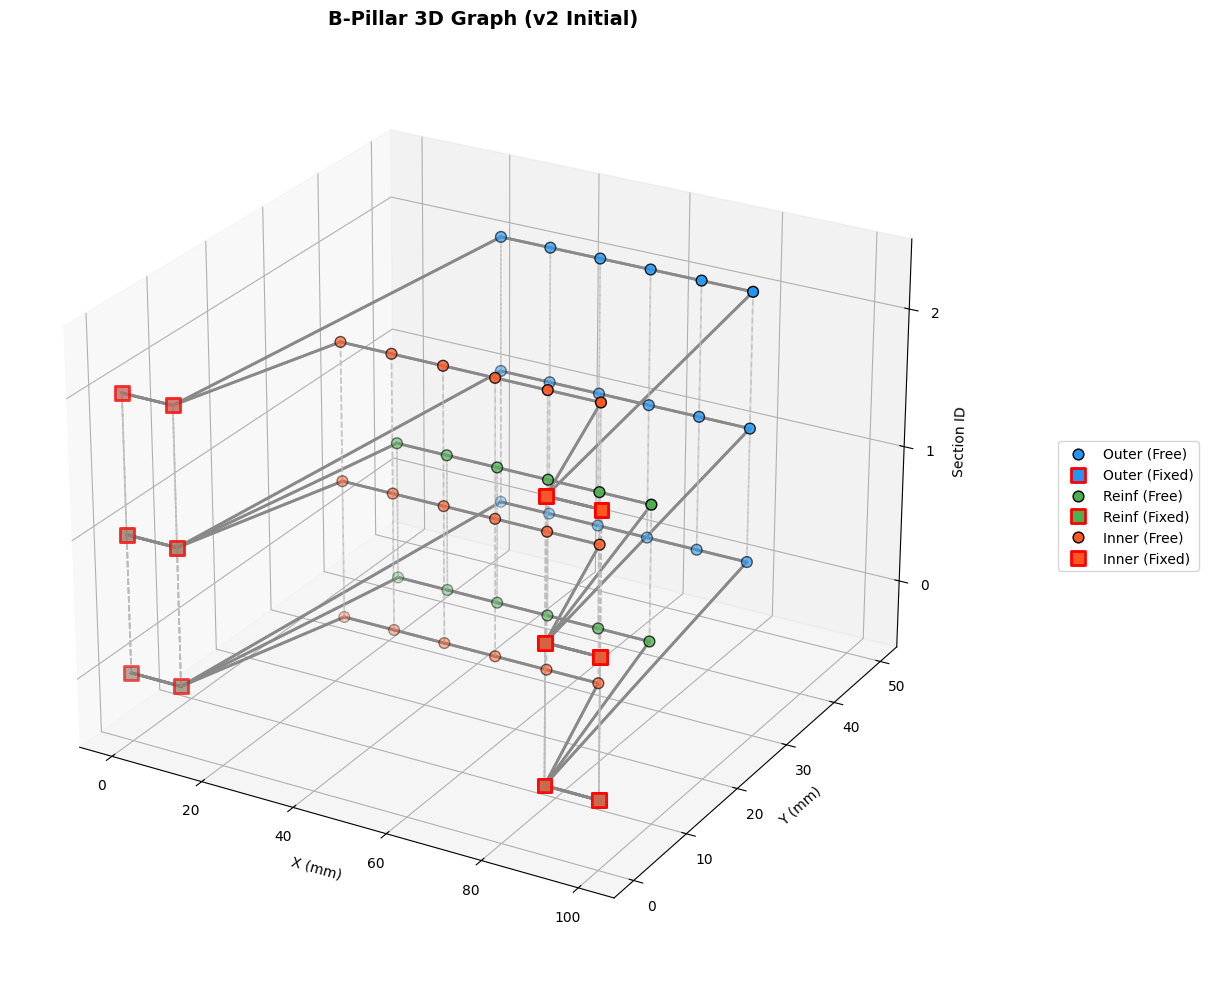

In [4]:
## ─────────────────────────────────────────────────────────────
## Data Construction (3 sections × 3 parts)
## ─────────────────────────────────────────────────────────────
"""
B-Pillar 3x3 구조:
  section 0 (1층): part 0(Outer), 1(Reinf), 2(Inner)
  section 1 (2층): part 0(Outer), 1(Reinf), 2(Inner)
  section 2 (3층): part 0(Outer), 2(Inner)  ← Reinf 없음

part별 두께/항복강도:
  - Outer (0): t=1.5mm, fy=1500 MPa
  - Reinf (1): t=2.0mm, fy=1500 MPa
  - Inner (2): t=1.5mm, fy=1200 MPa

고정점 (is_fixed=1): 양 끝 플랜지 노드 (i=0,1,8,9)
"""

num_nodes_total = 80
num_nodes = 10
x = torch.zeros((num_nodes_total, 7), dtype=torch.float32)

node_registry = {}
current_idx = 0

for section in [0, 1, 2]:
    parts_in_section = [0, 1, 2] if section in [0, 1] else [0, 2]

    for part in parts_in_section:
        for i in range(num_nodes):
            x_coord = i * (100.0 / 9.0)
            if i in [0, 1, 8, 9]:
                y_coord = 0.0
            else:
                y_coord = 20.0 if part == 2 else 30.0 if part == 1 else 50.0

            is_fixed = 1.0 if (i in [0, 1, 8, 9]) else 0.0
            t_val = 1.5 if part != 1 else 2.0
            fy_val = 1500.0 if part != 2 else 1200.0

            x[current_idx] = torch.tensor([x_coord, y_coord, is_fixed, part, section, t_val, fy_val])
            node_registry[(section, part, i)] = current_idx
            current_idx += 1

## ── Edge Construction ──
src_list, dst_list = [], []
edge_attr_list = []

def add_edge(u, v, part_id, edge_type):
    src_list.extend([u, v])
    dst_list.extend([v, u])
    dx = x[v, 0] - x[u, 0]
    dy = x[v, 1] - x[u, 1]
    length = math.sqrt(dx**2 + dy**2)
    angle = math.atan2(dy, dx)
    edge_attr_list.extend([[length, angle, part_id, edge_type],
                            [length, -angle, part_id, edge_type]])

# Intra-section (횡방향)
for section in [0, 1, 2]:
    parts = [0, 1, 2] if section in [0, 1] else [0, 2]
    for part in parts:
        for i in range(num_nodes - 1):
            u = node_registry[(section, part, i)]
            v = node_registry[(section, part, i+1)]
            add_edge(u, v, part_id=part, edge_type=0.0)

# Inter-section (종방향: 3D 연속성)
for section in [0, 1]:
    next_section = section + 1
    parts = [0, 2] if next_section == 2 else [0, 1, 2]
    for part in parts:
        for i in range(num_nodes):
            u = node_registry[(section, part, i)]
            v = node_registry[(next_section, part, i)]
            add_edge(u, v, part_id=part, edge_type=1.0)

# Flange binding (파트 끝점 결합)
for section in [0, 1, 2]:
    for i in [0, 9]:
        u0 = node_registry[(section, 0, i)]
        u2 = node_registry[(section, 2, i)]
        if section in [0, 1]:
            u1 = node_registry[(section, 1, i)]
            add_edge(u0, u1, part_id=0.0, edge_type=2.0)
            add_edge(u1, u2, part_id=0.0, edge_type=2.0)
        add_edge(u0, u2, part_id=0.0, edge_type=2.0)

edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
edge_attr = torch.tensor(edge_attr_list, dtype=torch.float32)

print(f"Nodes: {x.shape} | Edges: {edge_index.shape} | Edge Features: {edge_attr.shape}")


## ─────────────────────────────────────────────────────────────
## 3D Visualization
## ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

x_np = x.cpu().numpy()
ei_np = edge_index.cpu().numpy()
ea_np = edge_attr.cpu().numpy()

color_map = {0: '#2196F3', 1: '#4CAF50', 2: '#FF5722'}

for i in range(ei_np.shape[1]):
    u = ei_np[0, i]
    v = ei_np[1, i]
    e_type = ea_np[i, 3]
    xs = [x_np[u, 0], x_np[v, 0]]
    ys = [x_np[u, 1], x_np[v, 1]]
    zs = [x_np[u, 4], x_np[v, 4]]
    if e_type == 0.0:
        ax.plot(xs, ys, zs, color='#888888', linestyle='-', linewidth=2.0, alpha=0.9)
    elif e_type == 1.0:
        ax.plot(xs, ys, zs, color='#BBBBBB', linestyle='--', linewidth=1.2, alpha=0.6)
    elif e_type == 2.0:
        ax.plot(xs, ys, zs, color='red', linestyle=':', linewidth=3.0, alpha=0.9)

for part_id in [0, 1, 2]:
    mask = (x_np[:, 3] == part_id) & (x_np[:, 2] == 0.0)
    part_name = {0: 'Outer', 1: 'Reinf', 2: 'Inner'}[part_id]
    ax.scatter(x_np[mask, 0], x_np[mask, 1], x_np[mask, 4],
               c=color_map[part_id], marker='o', s=60, edgecolors='k', label=f'{part_name} (Free)')
    mask_fixed = (x_np[:, 3] == part_id) & (x_np[:, 2] == 1.0)
    if mask_fixed.any():
        ax.scatter(x_np[mask_fixed, 0], x_np[mask_fixed, 1], x_np[mask_fixed, 4],
                   c=color_map[part_id], marker='s', s=100, edgecolors='red', linewidths=2.0,
                   label=f'{part_name} (Fixed)')

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Section ID')
ax.set_title('B-Pillar 3D Graph (v2 Initial)', fontsize=14, fontweight='bold')
ax.set_zticks([0, 1, 2])
ax.set_zlim(-0.5, 2.5)
ax.view_init(elev=25, azim=-60)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.tight_layout()
plt.show()


Initial Mp:
  Section 2 (3층, Outer+Inner only): 804906 N·mm
  Section 1 (2층, all parts):        1150224 N·mm
  Section 0 (1층, all parts):        1082422 N·mm
CGDN v2 Training Log
Model params: 212,930
Epoch 000 | Loss: 657606.0000 | Mp: [1142862.125  1142855.      752058.4375] / [1500000, 1500000, 1000000] | Phys: 0.0583  Smth: 18553.7461  Coll: 3064.8521  Mono: 4392.8867  Cont: 0.0000
Epoch 010 | Loss: 888012.1875 | Mp: [1215566.625  1215593.875   786139.6875] / [1500000, 1500000, 1000000] | Phys: 0.0392  Smth: 40857688.0000  Coll: 3607.1714  Mono: 5122.1377  Cont: 0.0003
Epoch 020 | Loss: 485605.9375 | Mp: [1232112.75   1232068.25    792184.5625] / [1500000, 1500000, 1000000] | Phys: 0.0357  Smth: 3875101.5000  Coll: 3730.8191  Mono: 5292.0605  Cont: 0.0000
Epoch 030 | Loss: 421347.2812 | Mp: [1261887.625  1261872.25    804689.4375] / [1500000, 1500000, 1000000] | Phys: 0.0295  Smth: 3081005.2500  Coll: 3950.4141  Mono: 5587.5151  Cont: 0.0000
Epoch 040 | Loss: 387653.6250 | Mp: [12

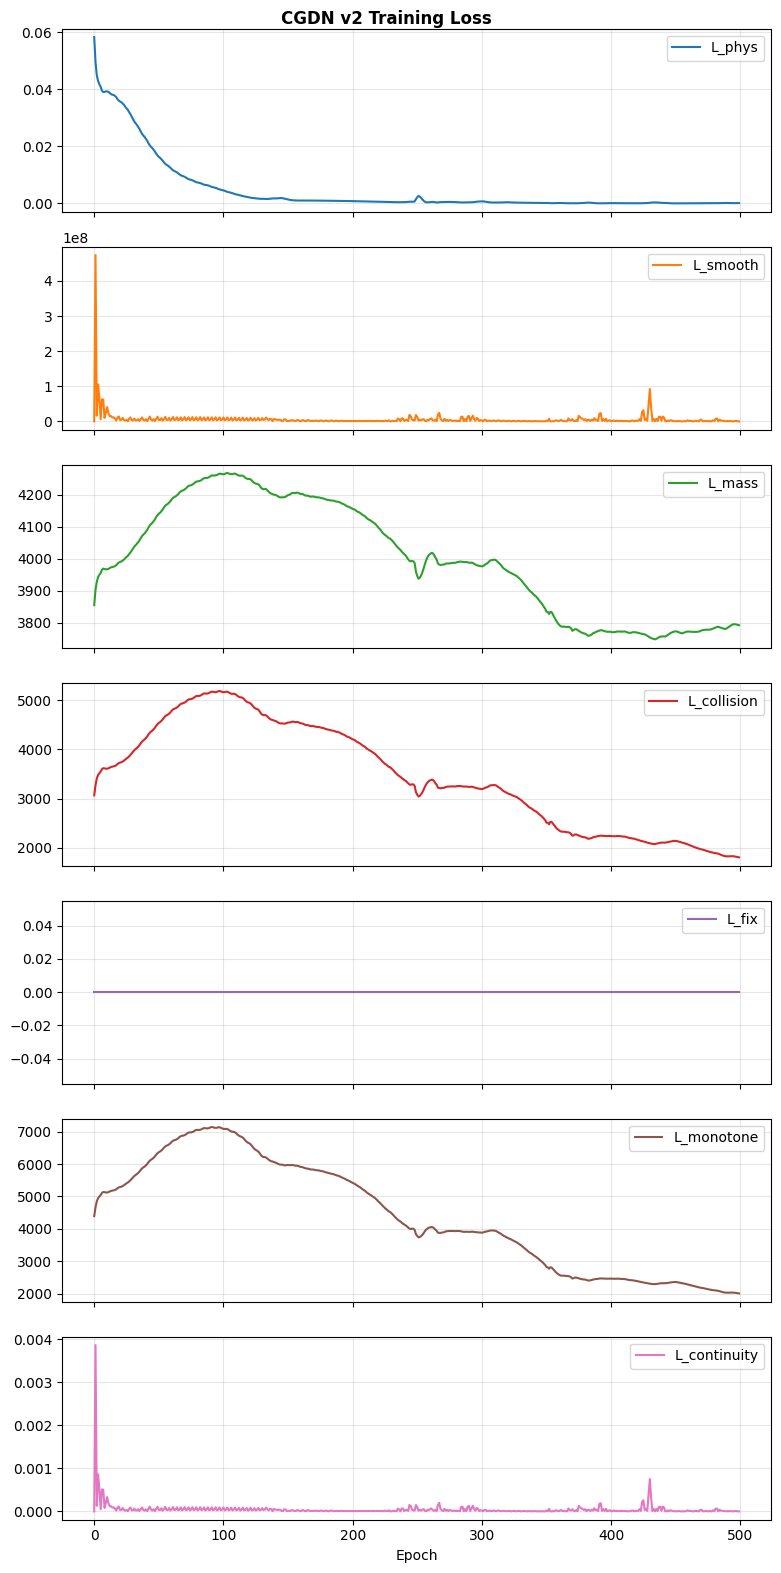

In [5]:
## ─────────────────────────────────────────────────────────────
## Initial Mp Check
## ─────────────────────────────────────────────────────────────

print(f"\nInitial Mp:")
print(f"  Section 2 (3층, Outer+Inner only): "
      f"{calculate_mpl(x[56:,:2], x[56:,5:6], x[56:,6:7], None):.0f} N·mm")
print(f"  Section 1 (2층, all parts):        "
      f"{calculate_mpl(x[28:56,:2], x[28:56,5:6], x[28:56,6:7], None):.0f} N·mm")
print(f"  Section 0 (1층, all parts):        "
      f"{calculate_mpl(x[:28,:2], x[:28,5:6], x[:28,6:7], None):.0f} N·mm")


## ─────────────────────────────────────────────────────────────
## Training
## ─────────────────────────────────────────────────────────────

if __name__ == "__main__":

    in_channels = 7
    hidden_channels = 128
    num_layers = 4
    heads = 4
    edge_feature_dim = 4
    learning_rate = 1e-3
    weight_decay = 1e-4
    max_epochs = 500
    target_mps = {0: 1500000, 1: 1500000, 2: 1000000}
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = CGDN(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        num_layers=num_layers,
        heads=heads,
        edge_dim=edge_feature_dim,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr).to(device)

    print("=" * 70)
    print("CGDN v2 Training Log")
    print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")
    print("=" * 70)

    loss_hist = []
    l_phys_hist = []
    l_smooth_hist = []
    l_mass_hist = []
    l_collision_hist = []
    l_fix_hist = []
    l_monotone_hist = []
    l_continuity_hist = []

    for epoch in range(max_epochs):
        info = train_step(model, data, optimizer, target_mps)

        l_phys_hist.append(info['l_phys'])
        l_smooth_hist.append(info['l_smooth'])
        l_mass_hist.append(info['l_mass'])
        l_collision_hist.append(info['l_collision'])
        l_fix_hist.append(info['l_fix'])
        l_monotone_hist.append(info['l_monotone'])
        l_continuity_hist.append(info['l_continuity'])
        loss_hist.append(info['loss'])

        if epoch % 10 == 0:
            target_mp_str = ', '.join(f'{target_mps[k]:.0f}' for k in sorted(target_mps))
            print(
                f"Epoch {epoch:03d} | "
                f"Loss: {info['loss']:.4f} | "
                f"Mp: {info['pred_mp']} / [{target_mp_str}] | "
                f"Phys: {info['l_phys']:.4f}  "
                f"Smth: {info['l_smooth']:.4f}  "
                f"Coll: {info['l_collision']:.4f}  "
                f"Mono: {info['l_monotone']:.4f}  "
                f"Cont: {info['l_continuity']:.4f}"
            )

    ## ── Loss 시각화 (7개 서브플롯) ──
    epochs = list(range(max_epochs))
    fig, axes = plt.subplots(7, 1, figsize=(8, 16), sharex=True)
    labels = ['L_phys', 'L_smooth', 'L_mass', 'L_collision', 'L_fix', 'L_monotone', 'L_continuity']
    hists  = [l_phys_hist, l_smooth_hist, l_mass_hist, l_collision_hist,
               l_fix_hist, l_monotone_hist, l_continuity_hist]

    for ax, lbl, hist, c in zip(axes, labels, hists, [f'C{i}' for i in range(7)]):
        ax.plot(epochs, hist, label=lbl, color=c)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
    axes[-1].set_xlabel('Epoch')
    plt.suptitle('CGDN v2 Training Loss', fontweight='bold')
    plt.tight_layout()
    plt.show()



Generating 2D Section Cross-sections...


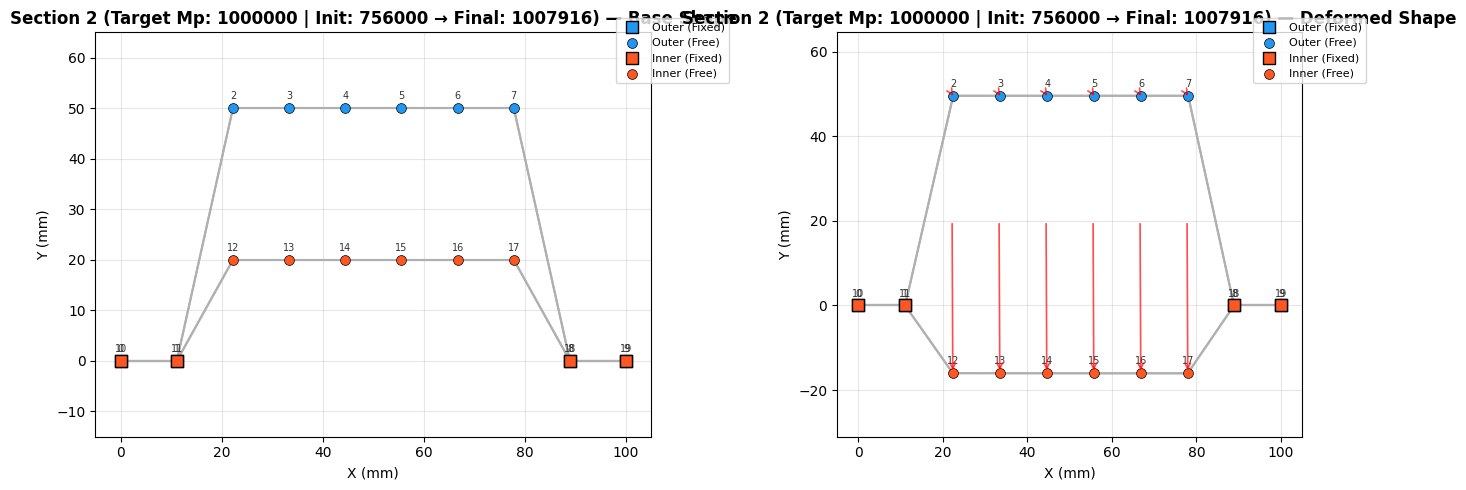

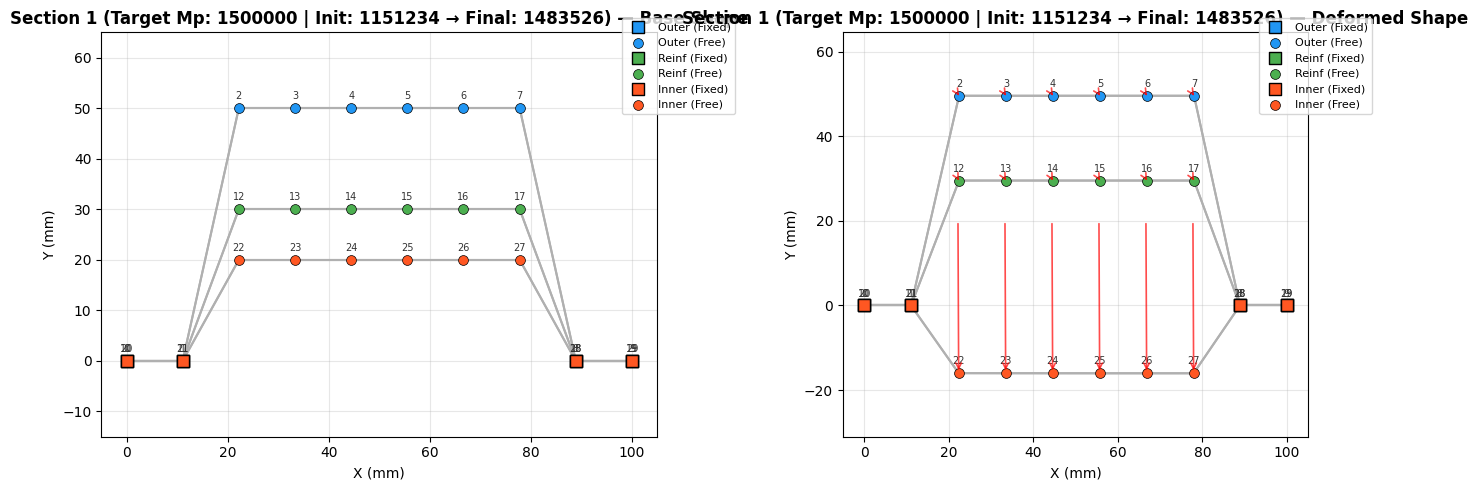

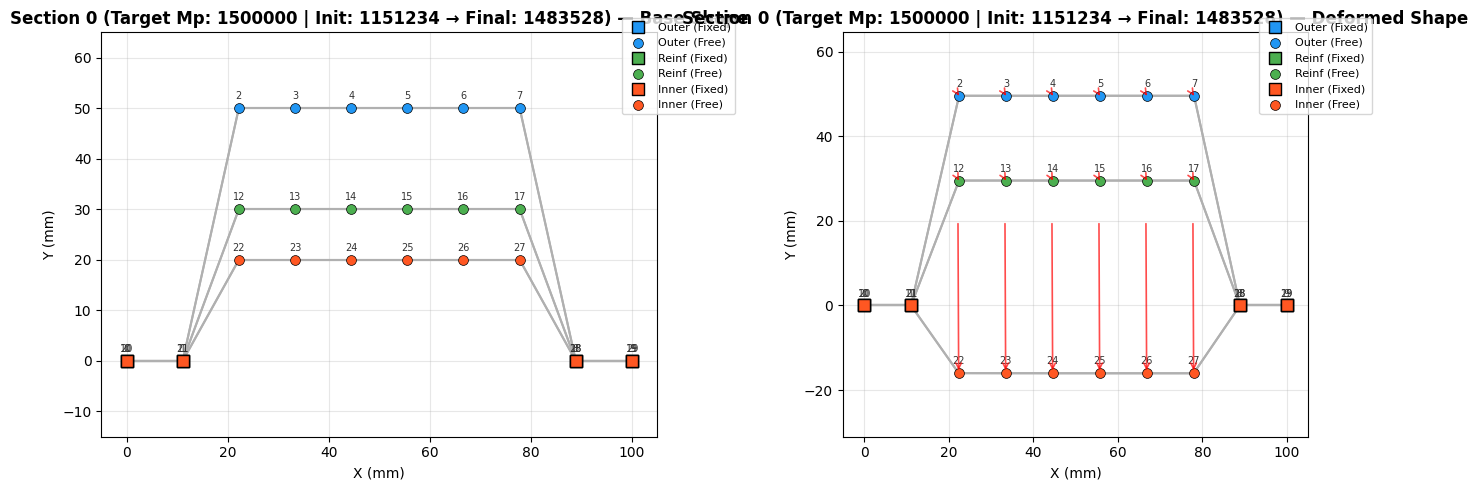


Generating 3D Visualization of Final Shape...


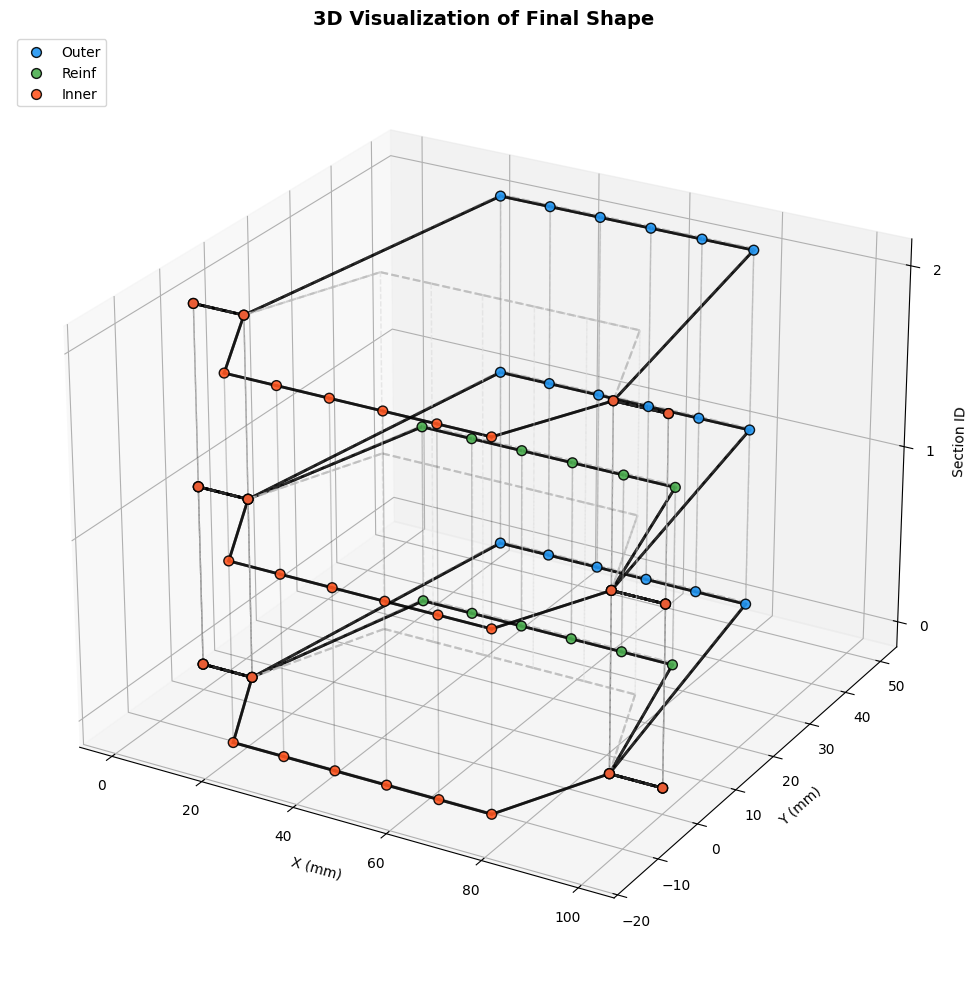

new coords: tensor([[  0.0000,   0.0000],
        [ 11.1111,   0.0000],
        [ 22.4829,  49.5858],
        [ 33.5945,  49.5861],
        [ 44.7058,  49.5858],
        [ 55.8171,  49.5857],
        [ 66.9284,  49.5858],
        [ 78.0398,  49.5852],
        [ 88.8889,   0.0000],
        [100.0000,   0.0000],
        [  0.0000,   0.0000],
        [ 11.1111,   0.0000],
        [ 22.4736,  29.5381],
        [ 33.5854,  29.5396],
        [ 44.6968,  29.5391],
        [ 55.8081,  29.5389],
        [ 66.9195,  29.5389],
        [ 78.0305,  29.5368],
        [ 88.8889,   0.0000],
        [100.0000,   0.0000],
        [  0.0000,   0.0000],
        [ 11.1111,   0.0000],
        [ 22.3818, -16.0026],
        [ 33.4936, -16.0163],
        [ 44.6056, -16.0268],
        [ 55.7176, -16.0327],
        [ 66.8297, -16.0340],
        [ 77.9418, -16.0319],
        [ 88.8889,   0.0000],
        [100.0000,   0.0000],
        [  0.0000,   0.0000],
        [ 11.1111,   0.0000],
        [ 22.4829,  49.5858]

In [6]:

## ─────────────────────────────────────────────────────────────
## 2D Section-by-Section Visualization (Base vs Deformed)
## ─────────────────────────────────────────────────────────────
def visualize_section(coords, edge_index, x_features, title="B-Pillar Cross Section",
                        deformed_coords=None, figsize=(14, 5), section_start=0):
    section_end = section_start + coords.shape[0]

    # 해당 섹션 내부의 엣지만 필터링 (Intra-section edges)
    mask = (edge_index[0] >= section_start) & (edge_index[0] < section_end) & \
            (edge_index[1] >= section_start) & (edge_index[1] < section_end)
    local_edge_index = edge_index[:, mask] - section_start

    is_fixed  = x_features[:, 2].cpu().numpy().astype(bool)
    part_ids  = x_features[:, 3].cpu().numpy().astype(int)
    coords_np = coords.cpu().detach().numpy()
    ei = local_edge_index.cpu().numpy()

    n_plots = 2 if deformed_coords is not None else 1
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    if n_plots == 1: axes = [axes]

    def _draw(ax, pts, subtitle):
        # 1. 엣지 렌더링
        for i in range(ei.shape[1]):
            s, d = ei[0, i], ei[1, i]
            ax.plot([pts[s, 0], pts[d, 0]], [pts[s, 1], pts[d, 1]],
                    color='#b0b0b0', linewidth=1.5, zorder=1)

        # 2. 노드 렌더링 (Outer, Reinf, Inner)
        colors_map = {0: '#2196F3', 1: '#4CAF50', 2: '#FF5722'} 
        marker_map = {True: 's', False: 'o'}        
        label_map  = {True: 'Fixed', False: 'Free'}
        part_name  = {0: 'Outer', 1: 'Reinf', 2: 'Inner'}

        for lid in [0, 1, 2]:
            for fix in [True, False]:
                mask_node = (part_ids == lid) & (is_fixed == fix)
                if not mask_node.any(): continue

                lbl = f'{part_name[lid]} ({label_map[fix]})'
                ax.scatter(pts[mask_node, 0], pts[mask_node, 1],
                            c=colors_map[lid], marker=marker_map[fix],
                            s=80 if fix else 50, edgecolors='k', linewidths=1.0 if fix else 0.5,
                            zorder=3, label=lbl)

        # 3. 노드 로컬 인덱스 표시
        for i in range(len(pts)):
            ax.annotate(str(i), (pts[i, 0], pts[i, 1]),
                        fontsize=7, ha='center', va='bottom',
                        xytext=(0, 5), textcoords='offset points', color='#333333')

        ax.set_title(subtitle, fontsize=12, fontweight='bold')
        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        # Y축 여백 확보 (범례나 텍스트 겹침 방지)
        y_min, y_max = pts[:, 1].min(), pts[:, 1].max()
        ax.set_ylim(y_min - 15, y_max + 15)
        ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.15, 1.05))

    # Base Shape 렌더링
    _draw(axes[0], coords_np, f'{title} — Base Shape')

    # Deformed Shape 및 변위 화살표 렌더링
    if deformed_coords is not None:
        def_np = deformed_coords.cpu().detach().numpy()
        _draw(axes[1], def_np, f'{title} — Deformed Shape')

        for i in range(len(coords_np)):
            dx = def_np[i, 0] - coords_np[i, 0]
            dy = def_np[i, 1] - coords_np[i, 1]
            if np.sqrt(dx**2 + dy**2) > 1e-3: # 미세 진동 무시
                axes[1].annotate('',
                    xy=(def_np[i, 0], def_np[i, 1]),
                    xytext=(coords_np[i, 0], coords_np[i, 1]),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.2, alpha=0.7))

    plt.tight_layout()
    plt.show()

## ── 시각화 실행부 ──
# Section 0, 1은 Outer, Reinf, Inner (각 10노드, 총 30)
# Section 2는 Outer, Inner (각 10노드, 총 20)
num_nodes_in_section = [30, 30, 20] 
section_offsets = [0, 30, 60] 

print("\n" + "="*70)
print("Generating 2D Section Cross-sections...")
print("="*70)

# 역순 출력: 3층(Top) -> 2층(Mid) -> 1층(Bottom)
for i in (2, 1, 0):
    s = section_offsets[i]
    e = s + num_nodes_in_section[i]

    base_coords = data.x[s:e, :2]              
    deformed    = info['new_coords'][s:e]      
    section_features = data.x[s:e, :]

    # 해당 섹션의 초기/최종 Mp값 추출
    target_mp_val = target_mps[i]
    initial_mp_val = calculate_mpl(base_coords, section_features[:, 5:6], section_features[:, 6:7], None).item()
    final_mp_val = info['pred_mp'][i]

    title_str = f'Section {i} (Target Mp: {target_mp_val:.0f} | Init: {initial_mp_val:.0f} → Final: {final_mp_val:.0f})'

    visualize_section(
        coords=base_coords,
        edge_index=data.edge_index,
        x_features=section_features,
        title=title_str,
        deformed_coords=deformed,
        section_start=s,
    )

## ─────────────────────────────────────────────────────────────
## 3D Visualization
## ─────────────────────────────────────────────────────────────
def visualize_3d_final_shape(base_coords, new_coords, edge_index, part_ids, section_ids, edge_attr):
    """
    최종 형상을 3D로 시각화하는 함수
    :param base_coords: 초기 좌표 (Base Shape)
    :param new_coords: 변형된 좌표 (Deformed Shape)
    :param edge_index: 엣지 연결 정보
    :param part_ids: 파트 ID (Outer, Reinf, Inner)
    :param section_ids: 섹션 ID (층 정보)
    :param edge_attr: 엣지 속성 (edge_type 포함)
    """
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    base_np = base_coords.cpu().numpy()
    deformed_np = new_coords.cpu().detach().numpy()
    edge_np = edge_index.cpu().numpy()
    part_np = part_ids.cpu().numpy()
    section_np = section_ids.cpu().numpy()
    edge_attr_np = edge_attr.cpu().numpy()

    color_map = {0: '#2196F3', 1: '#4CAF50', 2: '#FF5722'}  # Outer, Reinf, Inner 색상

    # 엣지 렌더링 (Base와 Deformed Shape)
    for i in range(edge_np.shape[1]):
        u, v = edge_np[:, i]
        xs_base = [base_np[u, 0], base_np[v, 0]]
        ys_base = [base_np[u, 1], base_np[v, 1]]
        zs_base = [section_np[u], section_np[v]]

        xs_def = [deformed_np[u, 0], deformed_np[v, 0]]
        ys_def = [deformed_np[u, 1], deformed_np[v, 1]]
        zs_def = [section_np[u], section_np[v]]

        edge_type = edge_attr_np[i, 3]  # edge_type: 0.0 (intra-section), 1.0 (inter-section)
        if edge_type == 0.0:  # 층 안의 엣지 (진하게)
            ax.plot(xs_base, ys_base, zs_base, color='#BBBBBB', linestyle='--', linewidth=1.5, alpha=0.7)
            ax.plot(xs_def, ys_def, zs_def, color='k', linestyle='-', linewidth=2.0, alpha=0.7)
        elif edge_type == 1.0:  # 층 간의 엣지 (연하게)
            ax.plot(xs_base, ys_base, zs_base, color='#DDDDDD', linestyle='--', linewidth=1.0, alpha=0.4)
            ax.plot(xs_def, ys_def, zs_def, color='k', linestyle='-', linewidth=1.0, alpha=0.1)

    # 노드 렌더링 (Deformed Shape)
    for part_id in [0, 1, 2]:  # Outer, Reinf, Inner
        mask = (part_np == part_id)
        ax.scatter(deformed_np[mask, 0], deformed_np[mask, 1], section_np[mask],
                   c=color_map[part_id], label={0: 'Outer', 1: 'Reinf', 2: 'Inner'}[part_id],
                   s=50, edgecolors='k', alpha=0.9)

    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_zlabel('Section ID')
    ax.set_title('3D Visualization of Final Shape', fontsize=14, fontweight='bold')
    ax.set_zticks([0, 1, 2])
    ax.view_init(elev=25, azim=-60)
    ax.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()


# ── 최종 형상 시각화 실행 ──
print("\n" + "="*70)
print("Generating 3D Visualization of Final Shape...")
print("="*70)

visualize_3d_final_shape(
    base_coords=data.x[:, :2],               # 초기 좌표
    new_coords=info['new_coords'],           # 최종 변형된 좌표
    edge_index=data.edge_index,              # 엣지 연결 정보
    part_ids=data.x[:, 3],                   # 파트 ID
    section_ids=data.x[:, 4],                # 섹션 ID
    edge_attr=data.edge_attr                 # 엣지 속성
)

print("new coords:", info['new_coords'])